In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [2]:
plt.rcParams['figure.figsize']=(15,4)
plt.style.use('dark_background')

In [3]:
stock_data=pd.read_csv("stock_data.csv",
                       parse_dates=True,
                       index_col=['Date'])
print(f"Shape of stock Data: {stock_data.shape}")
benchmark_data=pd.read_csv("benchmark_data.csv",
                           parse_dates=True,
                           index_col=['Date'])
print(f"Shape of Benchmark Data: {benchmark_data.shape}")                           

Shape of stock Data: (252, 2)
Shape of Benchmark Data: (261, 1)


In [4]:
dfs=[stock_data,benchmark_data]
for df in dfs:
    df.dropna(inplace=True)
    print('shape: ',df.shape)

shape:  (252, 2)
shape:  (252, 1)


In [5]:
print('heads'.upper())
for df in dfs:
    display(df.head())
print('tails'.upper()+'\n.........................')
for df in dfs:
    display(df.tail())

HEADS


,Amazon,Facebook
Date,,
2016-01-04,636.989990,102.220001
2016-01-05,633.789978,102.730003
2016-01-06,632.650024,102.970001
2016-01-07,607.940002,97.919998
2016-01-08,607.049988,97.330002


,S&P 500
Date,
2016-01-04,2012.66
2016-01-05,2016.71
2016-01-06,1990.26
2016-01-07,1943.09
2016-01-08,1922.03


TAILS
.........................


,Amazon,Facebook
Date,,
2016-12-23,760.590027,117.269997
2016-12-27,771.400024,118.010002
2016-12-28,772.130005,116.919998
2016-12-29,765.150024,116.349998
2016-12-30,749.869995,115.050003


,S&P 500
Date,
2016-12-23,2263.79
2016-12-27,2268.88
2016-12-28,2249.92
2016-12-29,2249.26
2016-12-30,2238.83


In [6]:
for i in range(len(dfs)):
    if i == 0:
        print('stock data'.title())
    else: print('benchmark data'.title())

    display(dfs[i].describe(include='all'))

Stock Data


,Amazon,Facebook
count,252.000000,252.000000
mean,699.523135,117.035873
std,92.362312,8.899858
min,482.070007,94.160004
25%,606.929993,112.202499
50%,727.875000,117.765000
75%,767.882492,123.902502
max,844.359985,133.279999


Benchmark Data


,S&P 500
count,252.000000
mean,2094.651310
std,101.427615
min,1829.080000
25%,2047.060000
50%,2104.105000
75%,2169.075000
max,2271.720000


In [7]:
# Standard  & Poor's 500 is most common benchmark for state of economy
# Dow Jones used to the main gauge for economic health of US
# It contains 30 companies and limited sectors
# Hence S&P is more commonly used: 500 large caps across sectors
# it misses small and medium caps (most of the economy) and gives disproportion to large indexes
# broad view of US economic health
# components are updated quarterly (different companies included based on marked cap> 6.1 b, US headquarter, 
# 50 public vote, adequate liquidity, and financial viability)

In [ ]:
# sharpe ratio: developed by Nobel Laureate William F Sharp
# Used to understand the return compared to  risk
# average return in excess of risk (missing word) rate per unit of volatility or total risk
# Volatility is a measure of price fluctuation
# risk-free rate is return with 0 risk
# higher ratios generally make for attractive investments
# pros: adjusts past or expected for excess risk; high is good when compared to similar funds with lower returns
# weaknesses: several, including: assumptions that investments are normally distributed

# modern portfolio theory states that adding assets to a portfolio that has low correlations can decrease risk w/o sacrificing return


<Figure size 800x800 with 0 Axes>

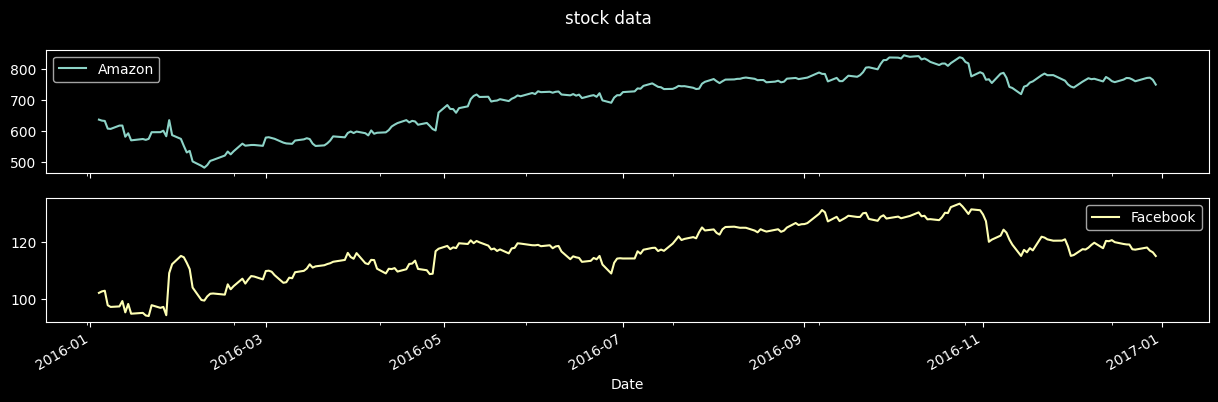

<Figure size 800x400 with 0 Axes>

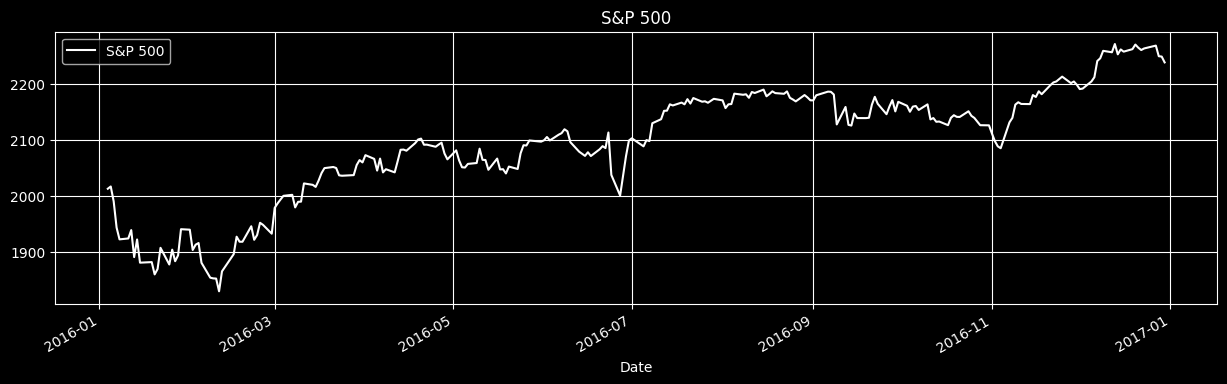

In [9]:
plt.figure(figsize=(8,8))
stock_data.plot(subplots = True, title='stock data')
plt.show()
plt.figure(figsize=(8,4))
benchmark_data.plot(title='S&P 500',color='white')
plt.grid()
plt.show()

In [10]:
for i in dfs:
    print(i.columns)

Index(['Amazon', 'Facebook'], dtype='object')
Index(['S&P 500'], dtype='object')


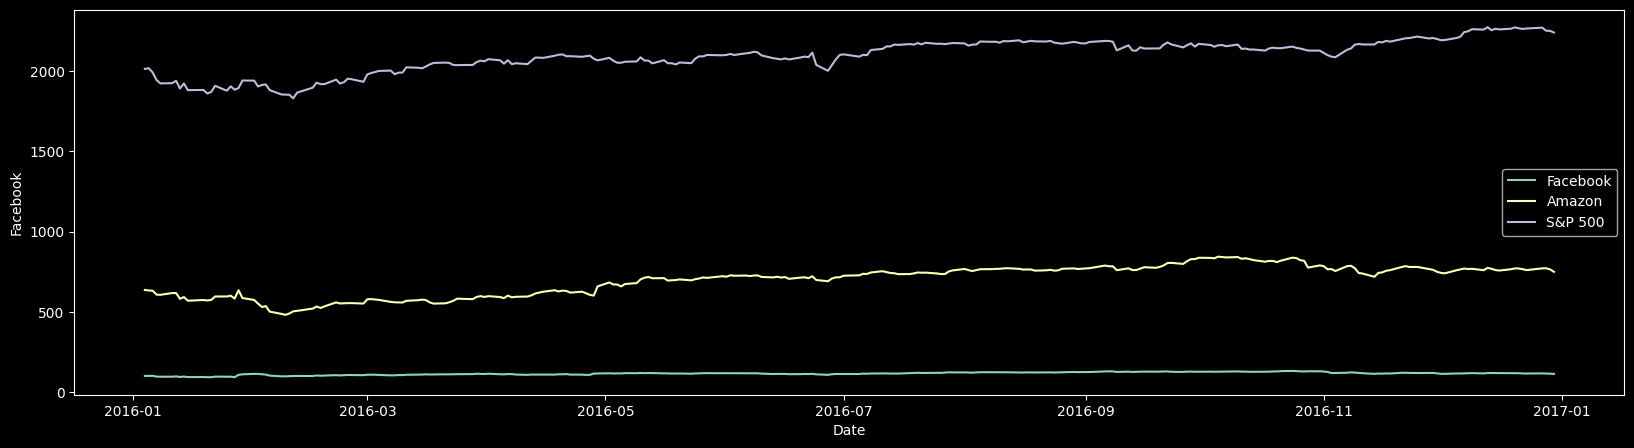

In [11]:
plt.figure(figsize=(20,5))
x=stock_data.index
sns.lineplot(x=x,y=stock_data['Facebook'],label='Facebook')
sns.lineplot(x=x,y=stock_data['Amazon'],label='Amazon')
sns.lineplot(x=x,y=benchmark_data['S&P 500'],label='S&P 500')
plt.legend()
plt.show()


In [12]:
# The Sharpe Ratio uses difference in returns
# data shows historical value, not return
# return is percentage change from one day to the next

<Figure size 2000x500 with 0 Axes>

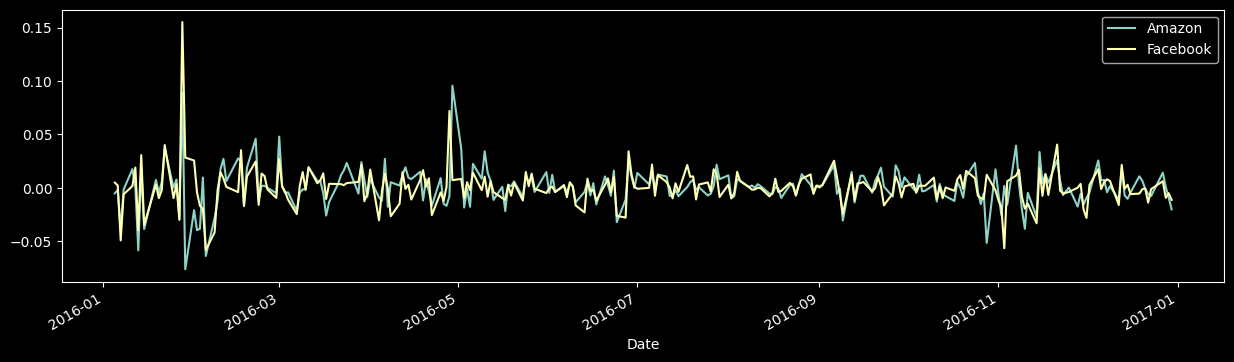

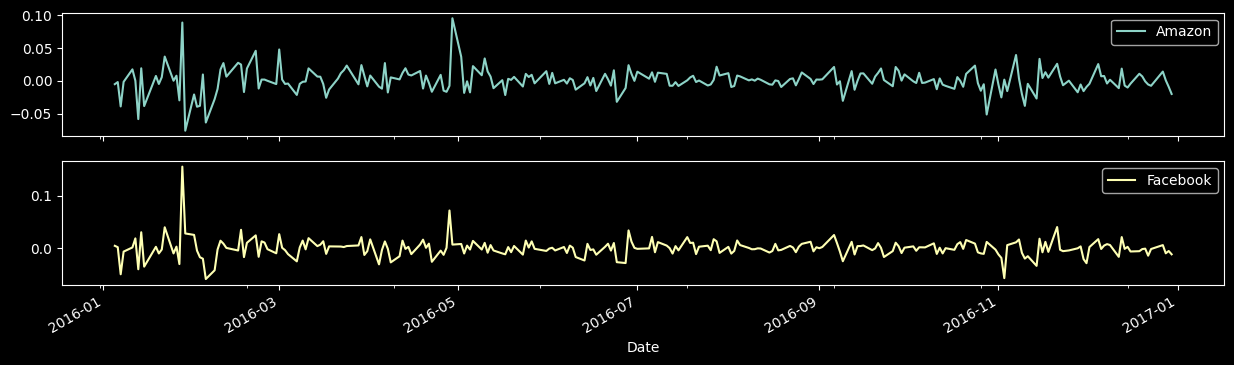

,Amazon,Facebook
count,252.000000,252.000000
mean,699.523135,117.035873
std,92.362312,8.899858
min,482.070007,94.160004
25%,606.929993,112.202499
50%,727.875000,117.765000
75%,767.882492,123.902502
max,844.359985,133.279999


In [13]:
stock_returns=stock_data.pct_change()

plt.figure(figsize=(20,5))
stock_returns.plot()
plt.show()
stock_returns.plot(subplots=True)
plt.show()
summary=stock_data.describe(include='all')
display(summary)

<Figure size 2000x500 with 0 Axes>

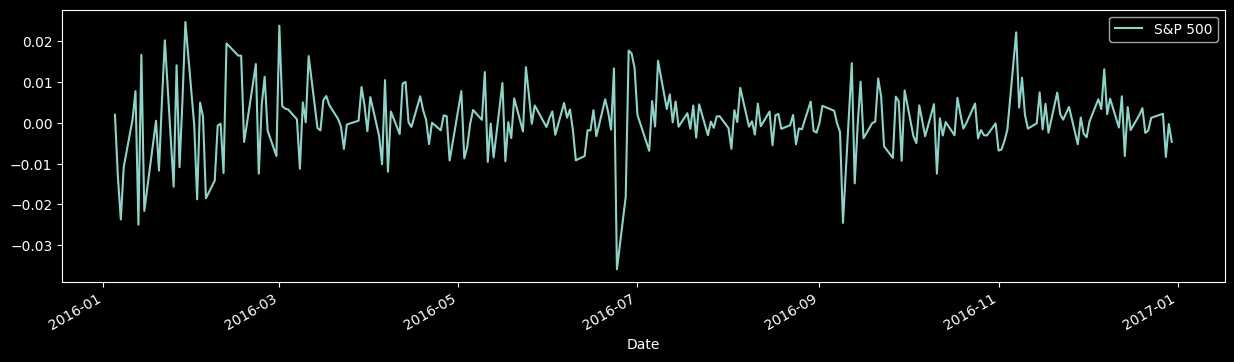

,S&P 500
count,252.000000
mean,2094.651310
std,101.427615
min,1829.080000
25%,2047.060000
50%,2104.105000
75%,2169.075000
max,2271.720000


In [14]:
benchmark_returns=benchmark_data.pct_change()

plt.figure(figsize=(20,5))
benchmark_returns.plot()
plt.show()

bench_summary=benchmark_data.describe(include='all')
display(bench_summary)

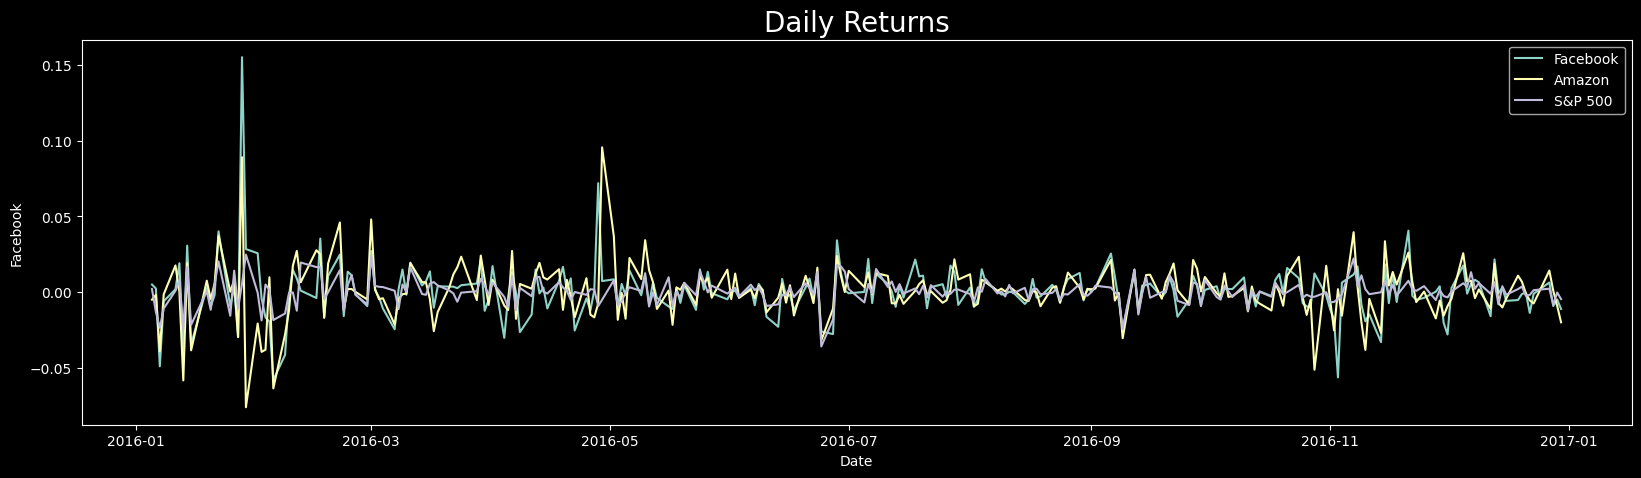

In [15]:
plt.figure(figsize=(20,5))
x=stock_returns.index
sns.lineplot(x=x,y=stock_returns['Facebook'],label='Facebook')
sns.lineplot(x=x,y=stock_returns['Amazon'],label='Amazon')
sns.lineplot(x=x,y=benchmark_returns['S&P 500'],label='S&P 500')
plt.legend()
plt.title('Daily Returns',fontsize=20)
plt.show()

In [16]:
stock_returns.dropna(inplace=True)
benchmark_returns.dropna(inplace=True)


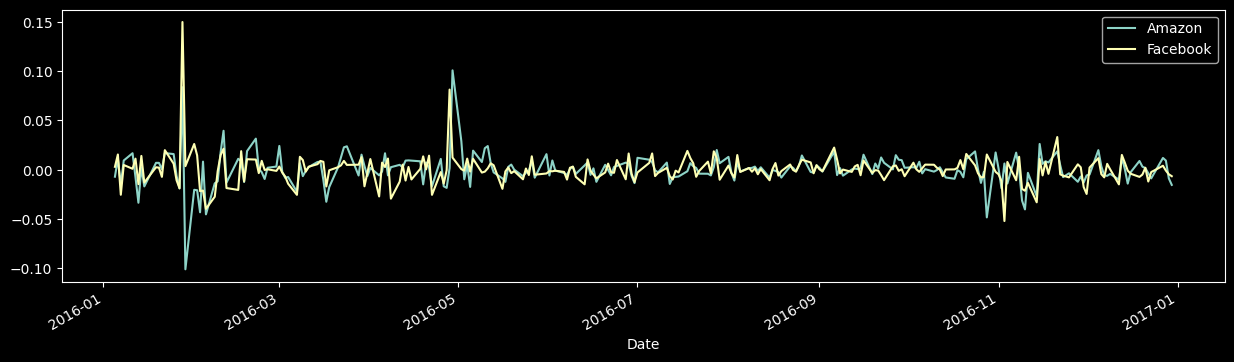

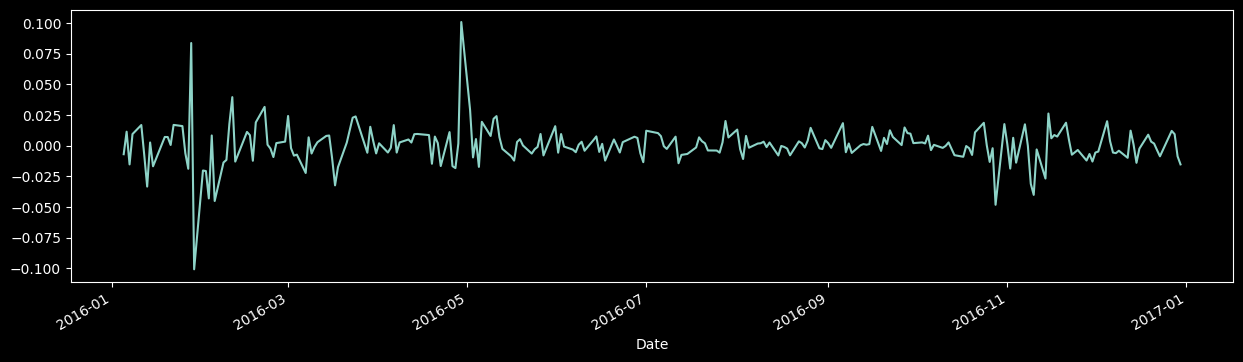

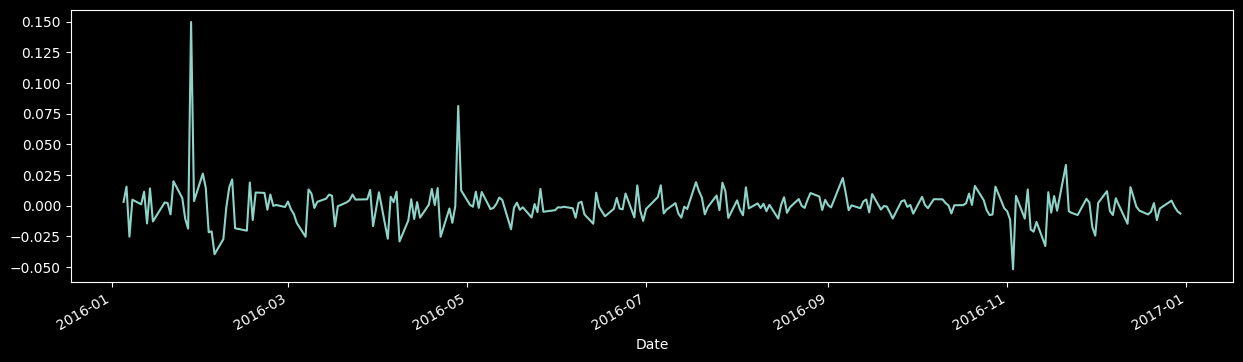

,Amazon,Facebook
count,251.000000,251.000000
mean,0.000360,0.000168
std,0.016126,0.015439
min,-0.100860,-0.051958
25%,-0.006229,-0.005663
50%,0.000698,-0.000454
75%,0.007351,0.005814
max,0.100728,0.149686


In [17]:

excess_returns=stock_returns.join([benchmark_returns])
excess_returns['Amazon']=excess_returns['Amazon']-excess_returns['S&P 500']
excess_returns['Facebook']=excess_returns['Facebook']-excess_returns['S&P 500']
excess_returns.drop(columns=['S&P 500'],inplace=True)
excess_returns.plot()
plt.show()
excess_returns['Amazon'].plot()
plt.show()
excess_returns['Facebook'].plot()
plt.show()
excess_summary=excess_returns.describe(include='all')
display(excess_summary)


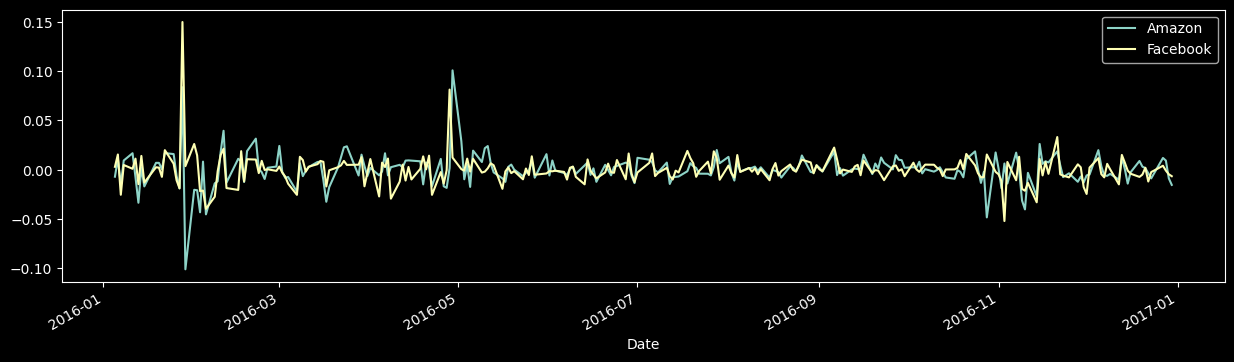

,Amazon,Facebook
count,251.000000,251.000000
mean,0.000360,0.000168
std,0.016126,0.015439
min,-0.100860,-0.051958
25%,-0.006229,-0.005663
50%,0.000698,-0.000454
75%,0.007351,0.005814
max,0.100728,0.149686


In [18]:

excess_returns.plot()
plt.show()
excess_summary=excess_returns.describe(include='all')
display(excess_summary)

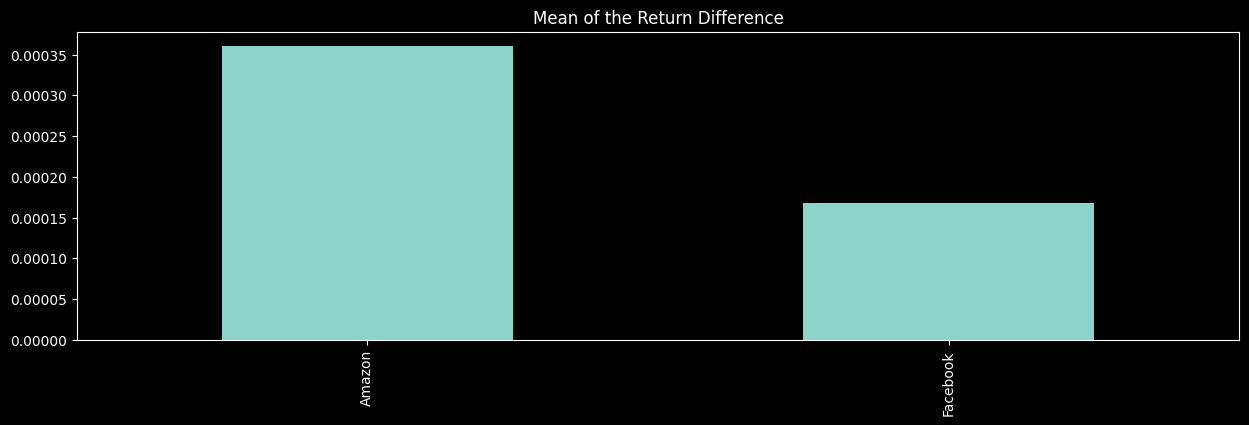

In [19]:
avg_excess_return = excess_returns.mean()
avg_excess_return.plot(kind='bar',title='Mean of the Return Difference')
plt.show()

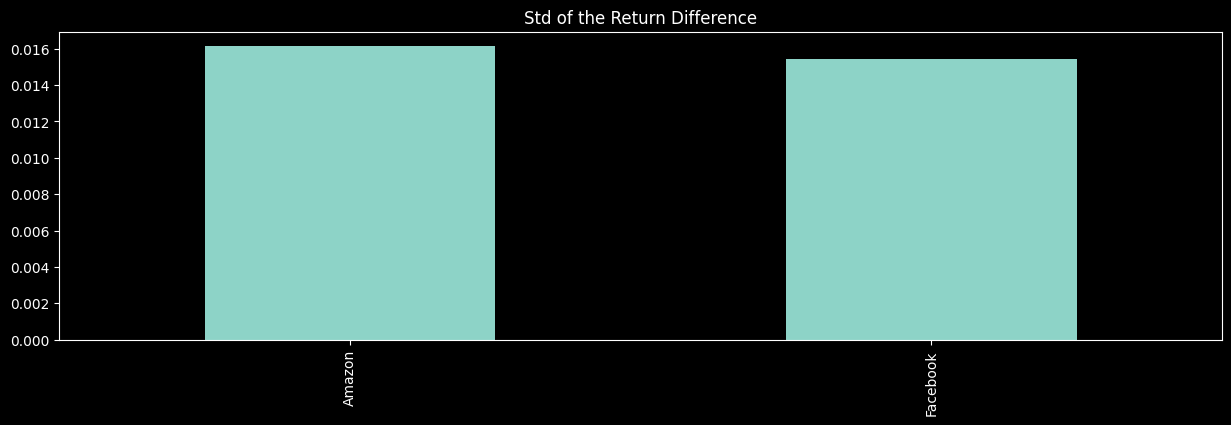

In [20]:
std_excess_return = excess_returns.std()
std_excess_return.plot(kind='bar',title='Std of the Return Difference')
plt.show()

In [21]:
# Compute the ratio of avg and std
# multiply it by sqr of num periods


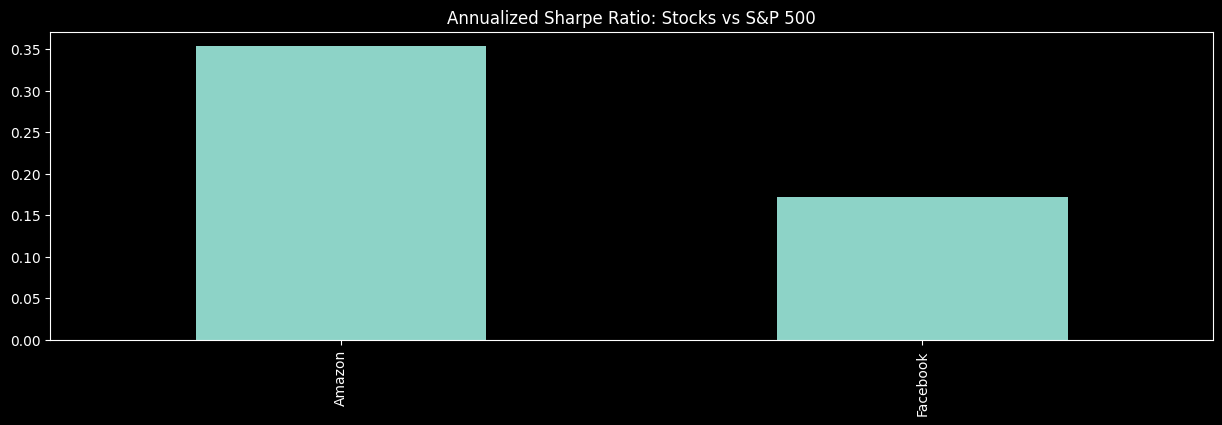

In [22]:
#daily sharp ratio
daily_sharp_ratio=avg_excess_return.div(std_excess_return)
annual_factor = np.sqrt(excess_returns.shape[0])
annual_sharpe_ratio=daily_sharp_ratio.mul(annual_factor)

annual_sharpe_ratio.plot(kind='bar',title='Annualized Sharpe Ratio: Stocks vs S&P 500')
plt.show()

findings:  
2016: Amazon had a sharpe ratio 2x Facebook  
investment in Amazon returned 2x compared to the S&P for each unit of risk  
risk adjusted return made Amazon more attractive  
difference was mostly in differences in return than in risk between Amazon and Facebook  ie high daily returns